# Network Intrusion Detection - Multi Model Pipeline Project
   ## Group Members:
   #### - Saad Yar Khan
   #### - Subhan
   #### - Nasir Hussain

### This notebook demonstrates a professional machine learning workflow using:

- `ColumnTransformer`
- `Pipeline`
- Multiple ML models
- Shared preprocessing
- Model evaluation
- Results comparison




### The Data Set:
     Dataset used: NSL-KDD / KDD Cup 1999 Intrusion Detection Dataset.
     https://www.unb.ca/cic/datasets/nsl.html

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
                                accuracy_score,
                                precision_score,
                                recall_score,
                                f1_score,
                                classification_report,
                                confusion_matrix
                            )

import warnings
warnings.filterwarnings('ignore')


### Load Dataset
     https://www.unb.ca/cic/datasets/nsl.html?utm_source=chatgpt.com
     https://www.kaggle.com/code/prthverm/cyber-security

In [40]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

In [41]:
train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

df = pd.concat([train_df, test_df], ignore_index=True)

print("Number of rows and columns:")
print(df.shape)
print("\n")
print("First five rcords of the dataset")
df.head()

Number of rows and columns:
(148517, 43)


First five rcords of the dataset


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


#### Features Desciption and Initial Data Exploration:
Concise feature descriptions suitable for adding into a Jupyter notebook documentation/markdown section for the KDD Cup 1999 Dataset / NSL-KDD intrusion detection dataset.

| Feature                       | Description                                                              |
| ----------------------------- | ------------------------------------------------------------------------ |
| `duration`                    | Length of the connection in seconds.                                     |
| `protocol_type`               | Type of protocol used (e.g., TCP, UDP, ICMP).                            |
| `service`                     | Network service on the destination (e.g., HTTP, FTP, Telnet).            |
| `flag`                        | Status flag of the connection indicating normal/error state.             |
| `src_bytes`                   | Number of data bytes sent from source to destination.                    |
| `dst_bytes`                   | Number of data bytes sent from destination to source.                    |
| `land`                        | 1 if source and destination IP/port are the same; otherwise 0.           |
| `wrong_fragment`              | Number of fragmented packets with incorrect offset.                      |
| `urgent`                      | Number of urgent packets in the connection.                              |
| `hot`                         | Number of suspicious or sensitive operations performed.                  |
| `num_failed_logins`           | Number of failed login attempts.                                         |
| `logged_in`                   | 1 if login was successful; otherwise 0.                                  |
| `num_compromised`             | Number of compromised conditions detected.                               |
| `root_shell`                  | 1 if root shell was obtained; otherwise 0.                               |
| `su_attempted`                | 1 if `su root` command was attempted; otherwise 0.                       |
| `num_root`                    | Number of root-level accesses or operations.                             |
| `num_file_creations`          | Number of file creation operations.                                      |
| `num_shells`                  | Number of shell prompts invoked.                                         |
| `num_access_files`            | Number of operations on access control files.                            |
| `num_outbound_cmds`           | Number of outbound commands in an FTP session.                           |
| `is_host_login`               | 1 if login belongs to host account list; otherwise 0.                    |
| `is_guest_login`              | 1 if login is a guest login; otherwise 0.                                |
| `count`                       | Number of connections to the same host in a given time window.           |
| `srv_count`                   | Number of connections to the same service in a given time window.        |
| `serror_rate`                 | Percentage of connections with SYN errors.                               |
| `srv_serror_rate`             | Percentage of same-service connections with SYN errors.                  |
| `rerror_rate`                 | Percentage of connections with REJ errors.                               |
| `srv_rerror_rate`             | Percentage of same-service connections with REJ errors.                  |
| `same_srv_rate`               | Percentage of connections to the same service.                           |
| `diff_srv_rate`               | Percentage of connections to different services.                         |
| `srv_diff_host_rate`          | Percentage of same-service connections to different hosts.               |
| `dst_host_count`              | Number of connections to the same destination host.                      |
| `dst_host_srv_count`          | Number of connections to the same service on destination host.           |
| `dst_host_same_srv_rate`      | Percentage of connections to same service on destination host.           |
| `dst_host_diff_srv_rate`      | Percentage of connections to different services on destination host.     |
| `dst_host_same_src_port_rate` | Percentage of connections from same source port.                         |
| `dst_host_srv_diff_host_rate` | Percentage of same-service connections to different hosts.               |
| `dst_host_serror_rate`        | Percentage of destination host connections with SYN errors.              |
| `dst_host_srv_serror_rate`    | Percentage of same-service destination host connections with SYN errors. |
| `dst_host_rerror_rate`        | Percentage of destination host connections with REJ errors.              |
| `dst_host_srv_rerror_rate`    | Percentage of same-service destination host connections with REJ errors. |
| `label`                       | Class label indicating normal traffic or attack type.                    |
| `difficulty`                  | Difficulty score assigned to classify the record correctly.              |



In [42]:
df.shape

(148517, 43)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     148517 non-null  int64  
 1   protocol_type                148517 non-null  object 
 2   service                      148517 non-null  object 
 3   flag                         148517 non-null  object 
 4   src_bytes                    148517 non-null  int64  
 5   dst_bytes                    148517 non-null  int64  
 6   land                         148517 non-null  int64  
 7   wrong_fragment               148517 non-null  int64  
 8   urgent                       148517 non-null  int64  
 9   hot                          148517 non-null  int64  
 10  num_failed_logins            148517 non-null  int64  
 11  logged_in                    148517 non-null  int64  
 12  num_compromised              148517 non-null  int64  
 13 

#### Missing Data Handling

In [44]:
df.isna().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

#### Duplicate Data Handling

In [45]:
df.duplicated().sum()

np.int64(610)

In [46]:
df.drop_duplicates(inplace=True)

#### The Target:

In [10]:
df['label'].unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl', 'saint', 'mscan', 'apache2',
       'snmpgetattack', 'processtable', 'httptunnel', 'ps', 'snmpguess',
       'mailbomb', 'named', 'sendmail', 'xterm', 'worm', 'xlock',
       'xsnoop', 'sqlattack', 'udpstorm'], dtype=object)

In [47]:
df['label'].value_counts()

label
normal             76967
neptune            45716
satan               4360
ipsweep             3643
smurf               3108
portsweep           3070
nmap                1566
back                1300
guess_passwd        1284
mscan                996
warezmaster          964
teardrop             901
warezclient          890
apache2              737
processtable         685
snmpguess            331
saint                319
mailbomb             293
pod                  221
snmpgetattack        178
httptunnel           133
buffer_overflow       50
multihop              25
rootkit               23
land                  22
named                 17
ps                    15
sendmail              14
xterm                 13
imap                  12
loadmodule            11
ftp_write             11
xlock                  9
phf                    6
perl                   5
xsnoop                 4
spy                    2
worm                   2
sqlattack              2
udpstorm           

#### Target Variable Visualization

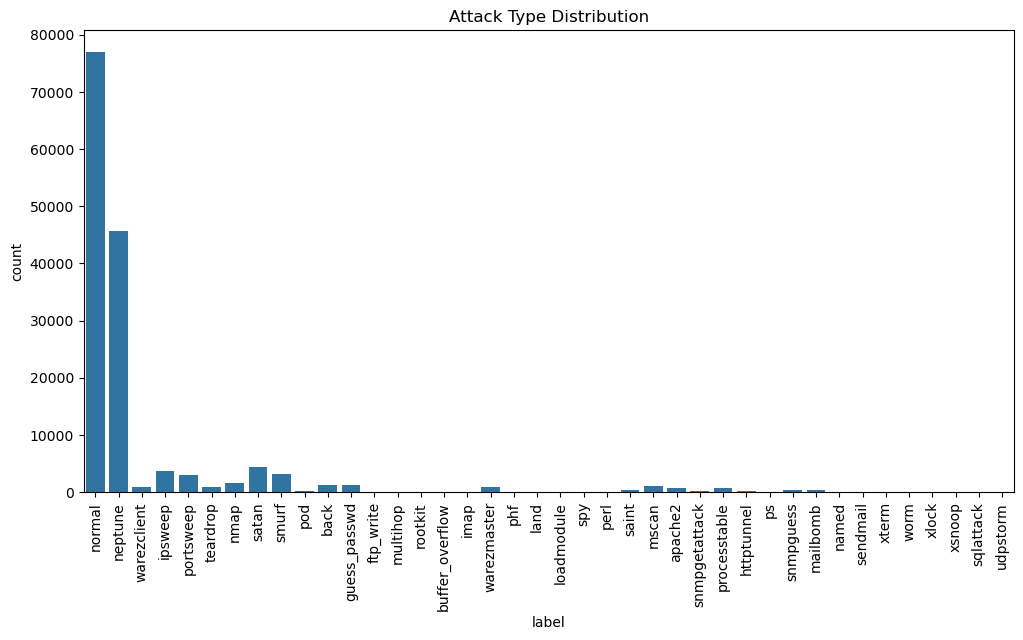

In [49]:
plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title('Attack Type Distribution')
plt.show()

#### Convert to Binary Classification

In [50]:
df['label'] = df['label'].apply( lambda x: 'normal' if x == 'normal' else 'attack')
df['label'].value_counts()


label
normal    76967
attack    70940
Name: count, dtype: int64

#### Target Variable Visualization

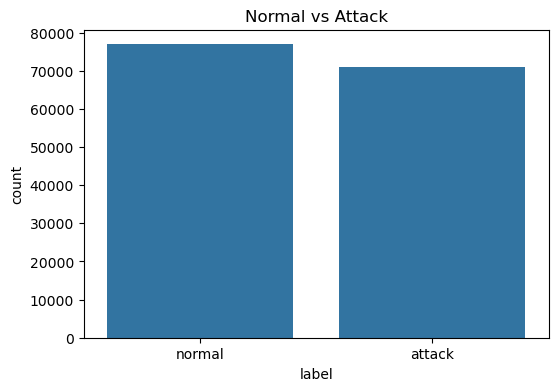

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Normal vs Attack')
plt.show()

#### Descriptive Statistics

In [52]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,147907.000000,1.479070e+05,1.479070e+05,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,...,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000
mean,277.920802,4.038680e+04,1.715835e+04,0.000196,0.020432,0.000203,0.189957,0.004341,0.404301,0.256012,...,119.388372,0.533852,0.084215,0.144211,0.030005,0.256797,0.251962,0.135927,0.136097,19.280670
std,2465.687803,5.420755e+06,3.711154e+06,0.014001,0.240040,0.019457,2.017189,0.072397,0.490758,22.277164,...,111.204986,0.447955,0.194118,0.306493,0.106307,0.428853,0.430083,0.322350,0.334929,2.742556
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,72.000000,0.590000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.780000e+02,5.800000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.050000,0.010000,0.630000,0.550000,0.000000,0.000000,21.000000
max,57715.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,101.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


#### Correlation Analysis

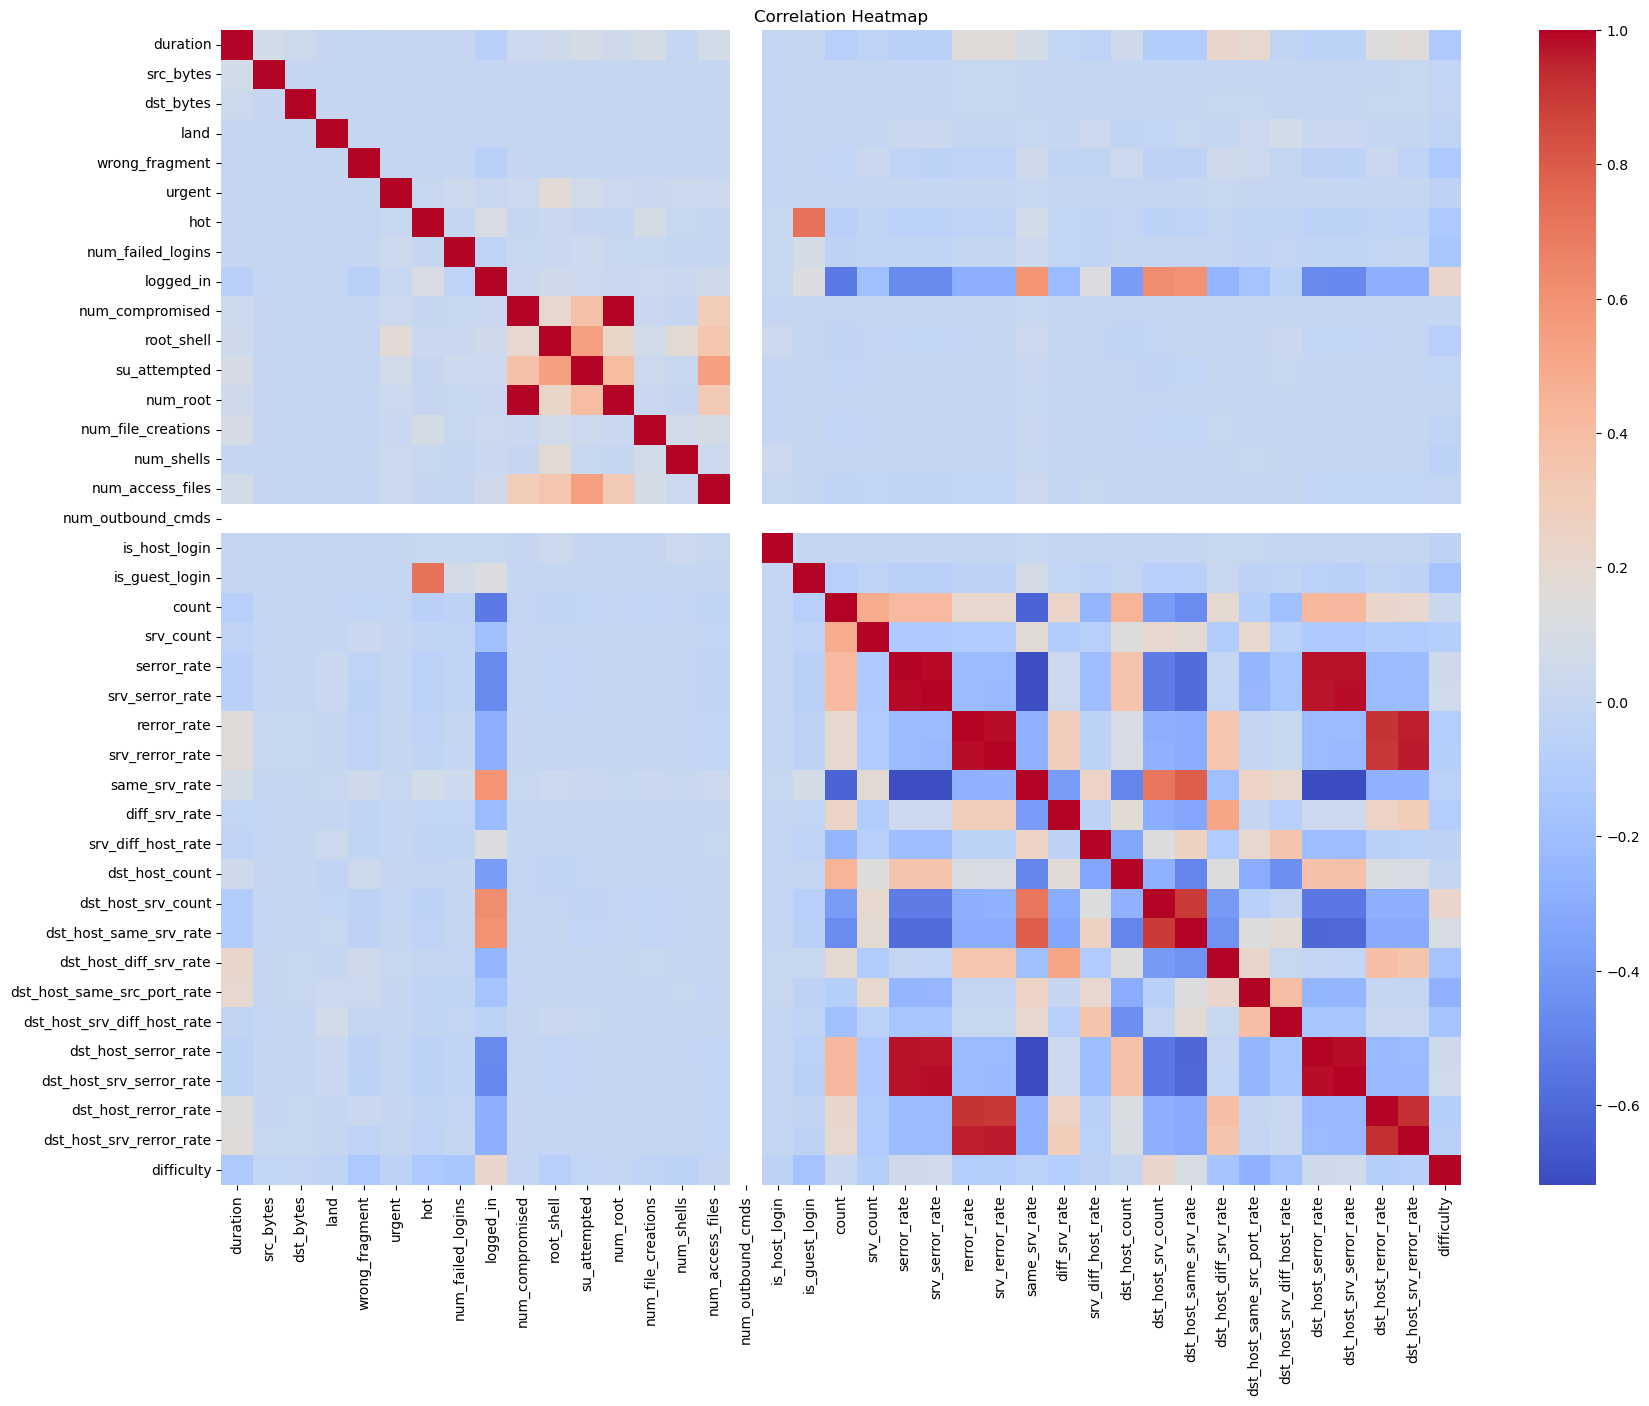

In [53]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(20,15))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#### Univariate Analysis

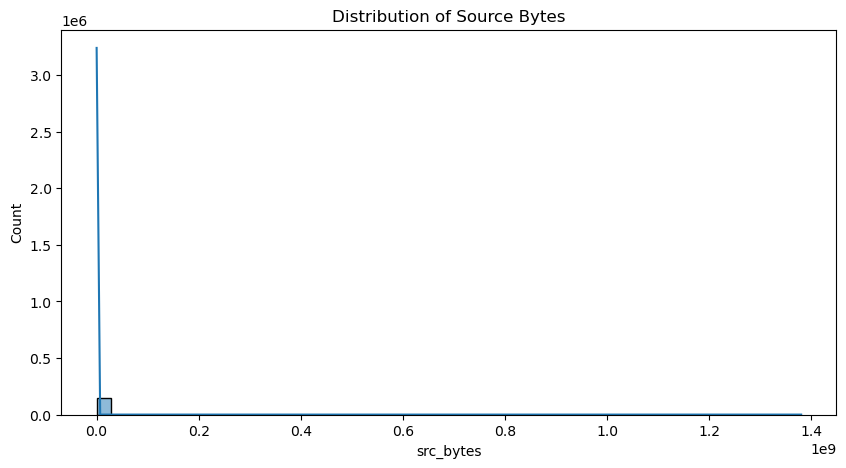

In [54]:
plt.figure(figsize=(10,5))
sns.histplot(df['src_bytes'], bins=50, kde=True)
plt.title('Distribution of Source Bytes')
plt.show()

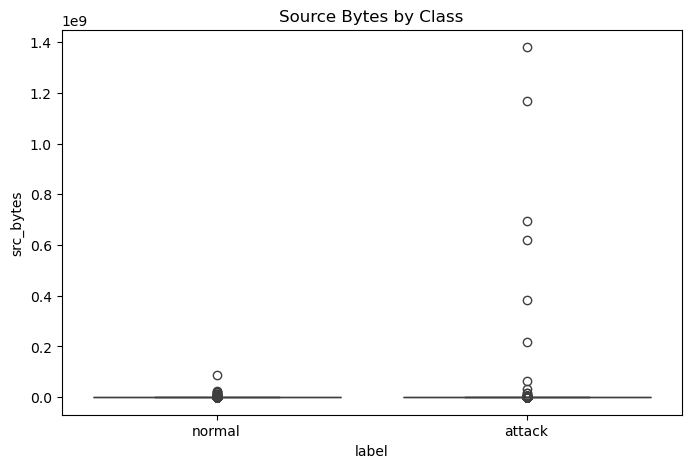

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='src_bytes', data=df)
plt.title('Source Bytes by Class')
plt.show()

#### Bivariate Analysis

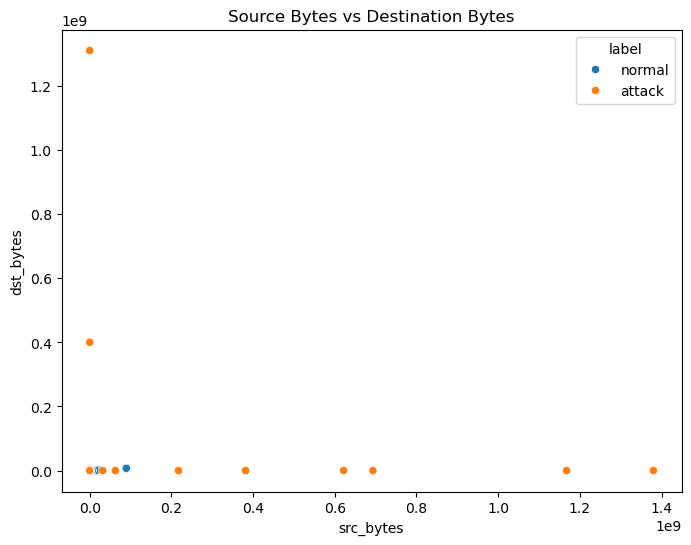

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='src_bytes',
    y='dst_bytes',
    hue='label',
    data=df
)
plt.title('Source Bytes vs Destination Bytes')
plt.show()


In [57]:
df.drop('difficulty', axis=1, inplace=True)

#### Separating Predictors and Target Variable

In [58]:
X= df.drop('label', axis=1)
y = df.label.replace(['normal','attack'],[0,1])

In [59]:
y.value_counts()

label
0    76967
1    70940
Name: count, dtype: int64

# Balancing Target CLasses 
## Synthetic Data Generation Using SMOTE / smote_nc

#### Splitting data into Training  and Testing sets

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
                                                        X,
                                                        y,
                                                        test_size=0.3,
                                                        random_state=42,
                                                        stratify=y
                                                    )

print(X_train.shape)
print(X_test.shape)


(103534, 41)
(44373, 41)


##### Separate Numerical and Categorical Columns

In [61]:
num_cols = X_train.select_dtypes(include=['int64', 'float64'])

cat_cols = X_train.select_dtypes(include=['object'])

print('Numerical Columns:\n', num_cols.columns.tolist())
print("\n")
print('Categorical Columns:', cat_cols.columns.tolist())

Numerical Columns:
 ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


Categorical Columns: ['protocol_type', 'service', 'flag']


In [62]:
y_train

83213     0
54006     0
19726     0
46122     1
119520    0
         ..
16342     1
48550     0
27483     1
45249     0
85552     0
Name: label, Length: 103534, dtype: int64

# Preprocessing Pipelines

In [63]:


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])




cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])



preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols.columns),
    ('cat', cat_pipeline, cat_cols.columns)
])

preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [64]:
# Fit on training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

In [65]:
cat_feature_indices = list(
    range(
        len(num_cols.columns.tolist()),
        len(num_cols.columns.tolist()) + len(cat_cols.columns.tolist())
    )
)

print(cat_feature_indices)

[38, 39, 40]


https://medium.com/analytics-vidhya/smote-nc-in-ml-categorization-models-fo-imbalanced-datasets-8adbdcf08c25

In [66]:
smote_nc = SMOTENC(categorical_features=cat_feature_indices,random_state=42)

X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train_processed,y_train)

print(X_train_resampled.shape)
print(y_train_resampled.shape)



(107752, 41)
(107752,)


Class blancing
label
0    53876
1    53876
Name: count, dtype: int64


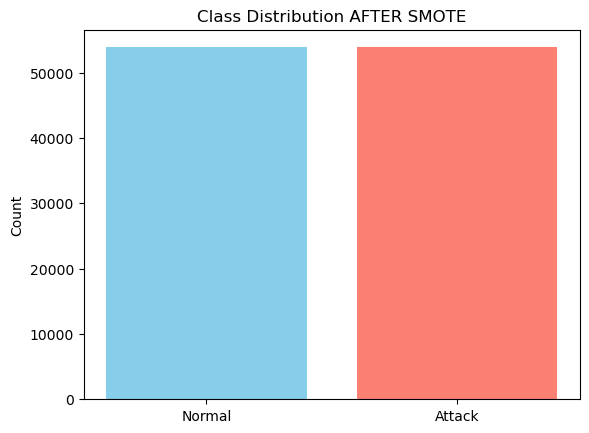

In [31]:
print("Class blancing")
print(y_train_resampled.value_counts())
plt.bar(y_train_resampled.value_counts().index, y_train_resampled.value_counts().values, color=['skyblue','salmon'])
plt.xticks([0,1], ['Normal', 'Attack'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(sampling_strategy='minority', random_state=42)

# X,y= smote.fit_resample(X_train,y_train)
# print("Class blancing")
# print(y.value_counts())
# plt.bar(y.value_counts().index, y.value_counts().values, color=['skyblue','salmon'])
# plt.xticks([0,1], ['Normal', 'Attack'])
# plt.ylabel("Count")
# plt.title("Class Distribution AFTER SMOTE")
# plt.show()


# Define Machine Learning Models


In [32]:
models = {

    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf'),
    'XGBoost': XGBClassifier(eval_metric='logloss',random_state=42)}

models


{'Logistic Regression': LogisticRegression(max_iter=1000),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'KNN': KNeighborsClassifier(),
 'SVM': SVC(),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               nu


# Train All Models Using Pipeline



Training Model: Logistic Regression


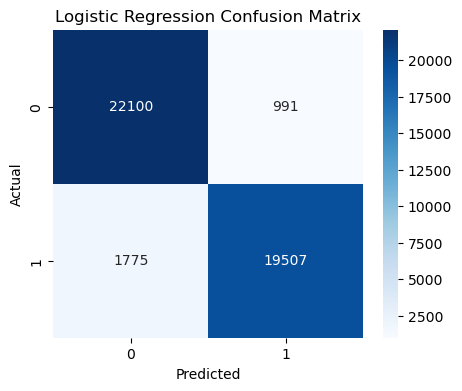

Accuracy : 0.9377
Precision: 0.9381
Recall   : 0.9377
F1 Score : 0.9376

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     23091
           1       0.95      0.92      0.93     21282

    accuracy                           0.94     44373
   macro avg       0.94      0.94      0.94     44373
weighted avg       0.94      0.94      0.94     44373


Training Model: Decision Tree


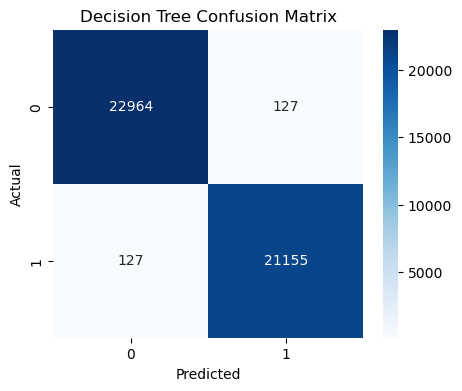

Accuracy : 0.9943
Precision: 0.9943
Recall   : 0.9943
F1 Score : 0.9943

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     23091
           1       0.99      0.99      0.99     21282

    accuracy                           0.99     44373
   macro avg       0.99      0.99      0.99     44373
weighted avg       0.99      0.99      0.99     44373


Training Model: Random Forest


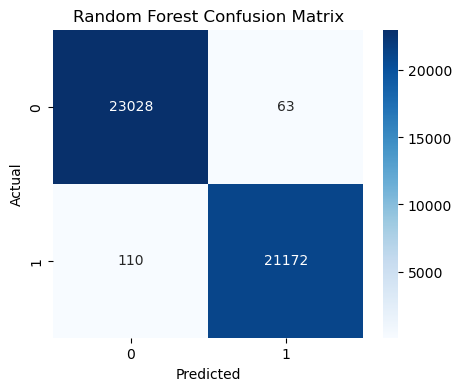

Accuracy : 0.9961
Precision: 0.9961
Recall   : 0.9961
F1 Score : 0.9961

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23091
           1       1.00      0.99      1.00     21282

    accuracy                           1.00     44373
   macro avg       1.00      1.00      1.00     44373
weighted avg       1.00      1.00      1.00     44373


Training Model: KNN


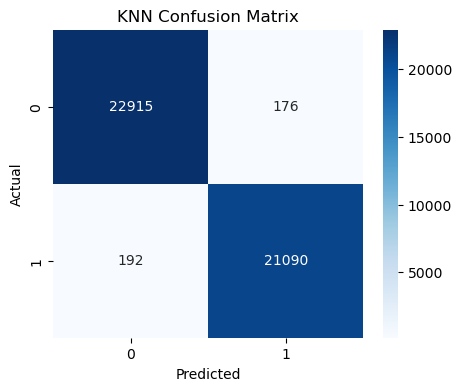

Accuracy : 0.9917
Precision: 0.9917
Recall   : 0.9917
F1 Score : 0.9917

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     23091
           1       0.99      0.99      0.99     21282

    accuracy                           0.99     44373
   macro avg       0.99      0.99      0.99     44373
weighted avg       0.99      0.99      0.99     44373


Training Model: SVM


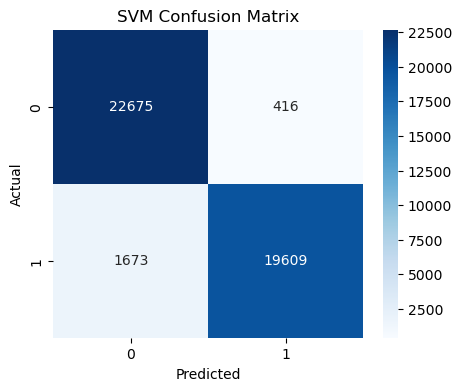

Accuracy : 0.9529
Precision: 0.9543
Recall   : 0.9529
F1 Score : 0.9528

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.96     23091
           1       0.98      0.92      0.95     21282

    accuracy                           0.95     44373
   macro avg       0.96      0.95      0.95     44373
weighted avg       0.95      0.95      0.95     44373


Training Model: XGBoost


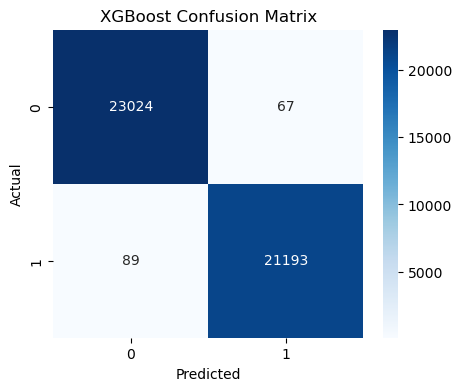

Accuracy : 0.9965
Precision: 0.9965
Recall   : 0.9965
F1 Score : 0.9965

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23091
           1       1.00      1.00      1.00     21282

    accuracy                           1.00     44373
   macro avg       1.00      1.00      1.00     44373
weighted avg       1.00      1.00      1.00     44373



In [33]:
results = []

trained_pipelines = {}

for name, model in models.items():

    print(f'\n=======================================')
    print(f'Training Model: {name}')
    print(f'=======================================')

    pipeline = Pipeline([
                        ('preprocessor', preprocessor),
                        ('model', model)
                      ])

    # Train
    pipeline.fit(X_train, y_train)

    # Save trained pipeline
    trained_pipelines[name] = pipeline

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score( y_test, y_pred, average='weighted' )

    recall = recall_score( y_test, y_pred, average='weighted')

    f1 = f1_score(y_test, y_pred,average='weighted')

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    
    results.append({
                    'Model': name,
                    'Accuracy': accuracy,
                    'Precision': precision,
                    'Recall': recall,
                    'F1 Score': f1
                })

    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1 Score : {f1:.4f}')

    print('\nClassification Report:\n')

    print(classification_report(y_test, y_pred))



# Results Comparison


In [34]:


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df


,Model,Accuracy,Precision,Recall,F1 Score
5,XGBoost,0.996484,0.996485,0.996484,0.996484
2,Random Forest,0.996101,0.996103,0.996101,0.996101
1,Decision Tree,0.994276,0.994276,0.994276,0.994276
3,KNN,0.991707,0.991707,0.991707,0.991707
4,SVM,0.952922,0.954280,0.952922,0.952829
0,Logistic Regression,0.937665,0.938124,0.937665,0.937600



# Best Performing Model


In [35]:
best_model = results_df.iloc[0]
print(best_model)

Model         XGBoost
Accuracy     0.996484
Precision    0.996485
Recall       0.996484
F1 Score     0.996484
Name: 5, dtype: object



# Predict Using Best Pipeline


In [36]:
best_model_name = results_df.iloc[0]['Model']

best_pipeline = trained_pipelines[best_model_name]

sample_prediction = best_pipeline.predict(X_test.iloc[:5])

print(sample_prediction)


[0 1 0 1 1]



# Hyperparameter Tuning Example:Grid Search


In [38]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)


{'model__max_depth': 10, 'model__n_estimators': 200}
0.9921475101761846


# Save the best Model Pipline

In [71]:
import pickle

with open('best_intrusion_detection_pipeline.pkl', 'wb') as file:
    pickle.dump(best_pipeline, file)

print('Pipeline saved successfully!')

Pipeline saved successfully!


In [72]:
with open('best_intrusion_detection_pipeline.pkl', 'rb') as file:
    loaded_pipeline = pickle.load(file)

print('Pipeline loaded successfully!')

Pipeline loaded successfully!


In [83]:
predictions = loaded_pipeline.predict(X_test.sample(10,random_state=42))

{indx:"Attack" if pred==1 else "Normal" for pred,indx in zip(predictions,X_test.sample(10,random_state=42).index)}

{25715: 'Attack',
 92485: 'Normal',
 44189: 'Normal',
 17903: 'Normal',
 98406: 'Attack',
 116910: 'Normal',
 82248: 'Normal',
 89688: 'Normal',
 136596: 'Attack',
 120038: 'Attack'}

In [84]:
X_test.sample(10, random_state=1234).to_csv('test_data.csv')